<a href="https://colab.research.google.com/github/Siddharth5723/Daily_learning/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline


In [ ]:
data = {
    'age': [18, 21, 23, 26, 29, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61, 64, 67, 70, 73],
    'insurance': [0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
df.head()

,age,insurance
0,18,0
1,21,0
2,23,0
3,26,0
4,29,1


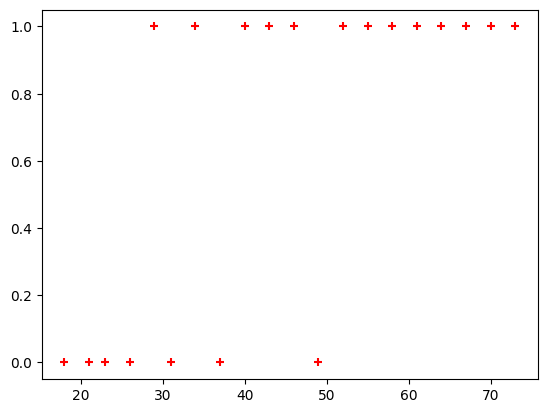

In [ ]:
plt.scatter(df.age,df.insurance,marker='+',color='red')

In [ ]:
df.shape

(20, 2)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(df[['age']],df.insurance,test_size=0.1)

In [ ]:
X_test

,age
17,67
13,55


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
model.predict(X_test)

array([1, 1])

In [ ]:
model.score(X_test,Y_test)

1.0

In [ ]:
y_predicted = model.predict(X_test)

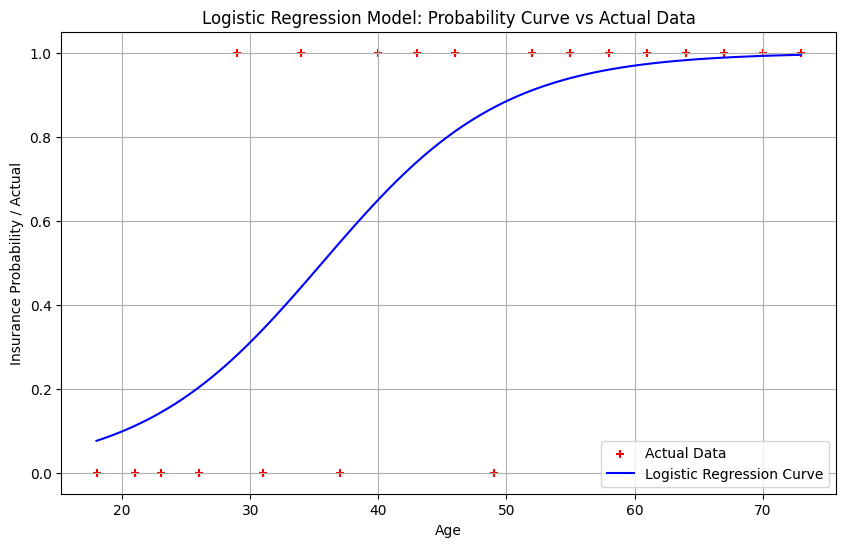

In [ ]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(df.age, df.insurance, marker='+', color='red', label='Actual Data')

# Generate a range of ages for plotting the logistic regression curve
X_curve = pd.DataFrame({'age': np.linspace(df['age'].min(), df['age'].max(), 100)})
y_proba_curve = model.predict_proba(X_curve)[:, 1] # Probability of 'insurance'=1
plt.plot(X_curve.age, y_proba_curve, color='blue', label='Logistic Regression Curve')

plt.xlabel('Age')
plt.ylabel('Insurance Probability / Actual')
plt.title('Logistic Regression Model: Probability Curve vs Actual Data')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
#Recognizing hand written digits
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

In [5]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [6]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

<Figure size 640x480 with 0 Axes>

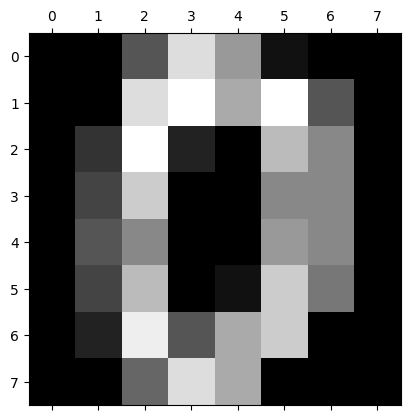

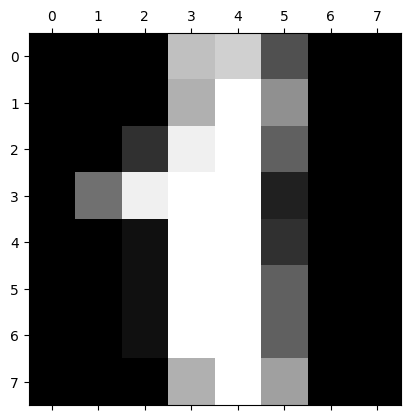

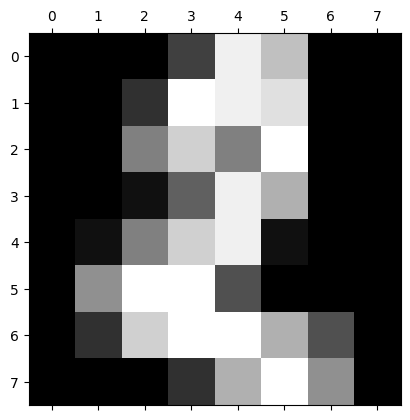

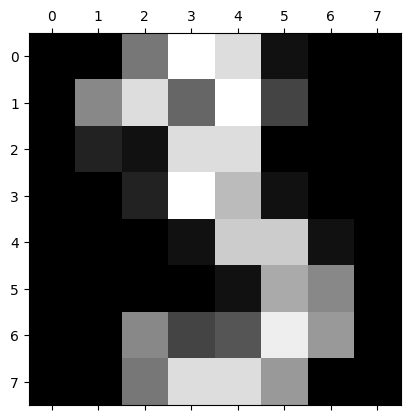

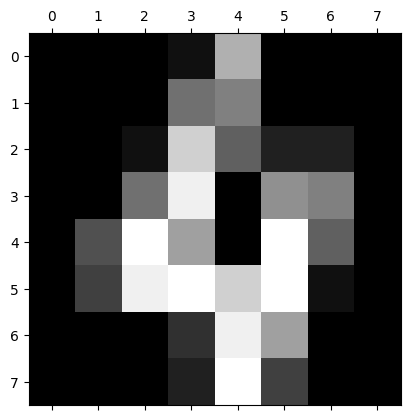

In [10]:
plt.gray()
for i in range(0,5):
  plt.matshow(digits.images[i])

In [11]:
digits.target[0:5]

array([0, 1, 2, 3, 4])

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train , x_test , y_train , y_test = train_test_split(digits.data , digits.target , test_size=0.2)

In [14]:
len(x_train)

1437

In [15]:
len(x_test)

360

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [17]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [18]:
model.score(x_test,y_test)

0.9722222222222222

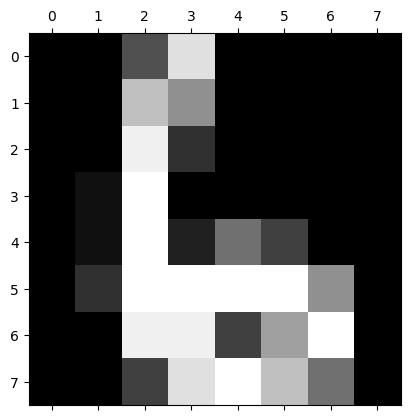

In [20]:
plt.matshow(digits.images[67])

In [21]:
digits.target[67]

np.int64(6)

In [22]:
model.predict(digits.data[[67]])

array([6])

In [23]:
model.predict(digits.data[0:5])

array([0, 1, 2, 3, 4])

In [24]:
y_predicted = model.predict(x_test)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test , y_predicted)
cm

array([[28,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 33,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1, 33,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 36,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0, 42,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 30,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 38,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 32,  0,  0],
       [ 0,  0,  1,  1,  0,  1,  0,  0, 38,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  4, 40]])

Text(95.72222222222221, 0.5, 'Truth')

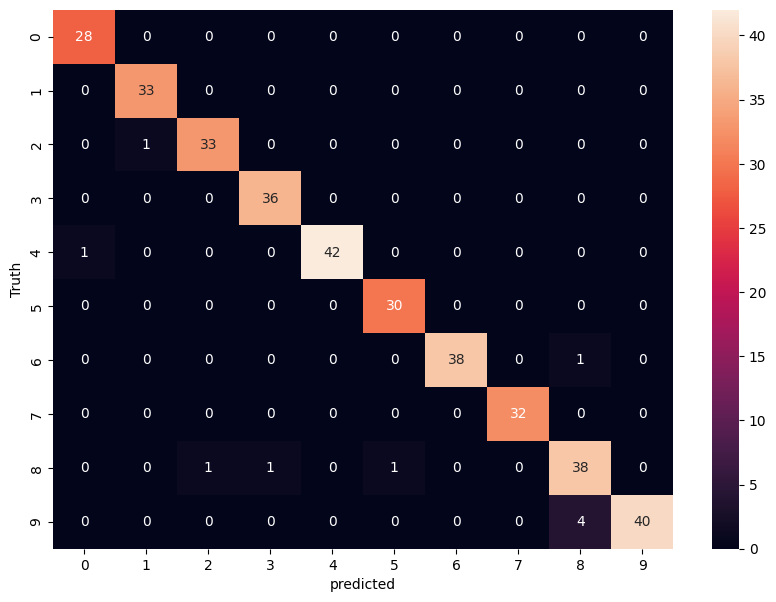

In [26]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm , annot=True)
plt.xlabel("predicted")
plt.ylabel("Truth")
#places where it is one , that is where the model went wrong during prediction